# FoodHub Order Analysis

Exploratory data analysis of food-delivery orders placed through **FoodHub**, a food-aggregator app operating in New York City.

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [160]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [161]:
# suppress warnings
import warnings
warnings.filterwarnings('ignore')

### Understanding the structure of the data

In [163]:
# read the data
df = pd.read_csv('data/foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### Dataset dimensions

In [164]:
# print out dimensions of the data (row, column)
df.shape

(1898, 9)

#### Observations:
By using the shape attribute, we can get the dimensions of the data. In the data, there are 1898 rows and 9 columns.

### Column data types

In [165]:
# Use info() to print a concise summary of the DataFrame
# print a concise summary of the DataFrame (column names, data type, null value count)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
There are mainly three different data types; int64, float64, and object. int64 and float64 are for numerical data and object is for categorical data. The order_id, customer_id, food_preparation_time, and delivery_time are the integer type data. cost_of_the_order is a float type data. For the object type data, there is restaurant_name, cuisine_type, day_of_the_week, and rating. Rating is supposed to be numerical data, but because there are answers like "Not given," it is counted as an object type data.

### Checking for missing values

In [166]:
# isnull(): check if there are any null values
# values: extracts an array from the previous function
# any(): returns true if there are any true values, returns false if there are no true values
df.isnull().values.any()

False

#### Observations:
The function above checks whether there are any missing values. If it outputs True, there is missing data, and if it outputs False, there isn't missing data.
Since the output says False, there is no missing value in the data.

### Statistical summary

We also note the minimum, average, and maximum food-preparation time.

In [167]:
# gives the numerical summary of the numerical data in the dataframe (e.g., mean, standard deviation, quartile)
# if you want to see the categorical data, too, you can add include='all' as a parameter
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


#### Observations:
We can check the food_preparation_time column for this answer.
The minimum, average, and maximum time it takes for food to be preapared once an order is placed is 20 minutes, 27.37 minutes, and 35 minutes, respectively.

### Unrated orders

In [168]:
# Write the code here
# counts the frequency of the unique values of the categorical data
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


#### Observations:
According to the output, there are 736 orders that are not rated.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### Exploring the distribution of each variable

In [169]:
# Write the code here
# check unique values of order_id
df['order_id'].nunique()

1898

All of the order_id values are unique. There are no repeated values.

In [170]:
# check unique values of customer_id
df['customer_id'].nunique()

1200

Some of the customer_id are repeated. Some customer ordered more than 2 times.

In [171]:
# check unique values of restaurant_name
df['restaurant_name'].nunique()

178

In [172]:
# find the top 10 most ordered restaurants
df['restaurant_name'].value_counts().head(10)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68
RedFarm Broadway,59
RedFarm Hudson,55
TAO,49
Han Dynasty,46


THere are too many restuarant_names to make it into a count plot. However, we can look at the top 10 (or even more) most ordered restaurants by using value_counts().

In [173]:
# check unique values of cuisine_type
df['cuisine_type'].nunique()

14

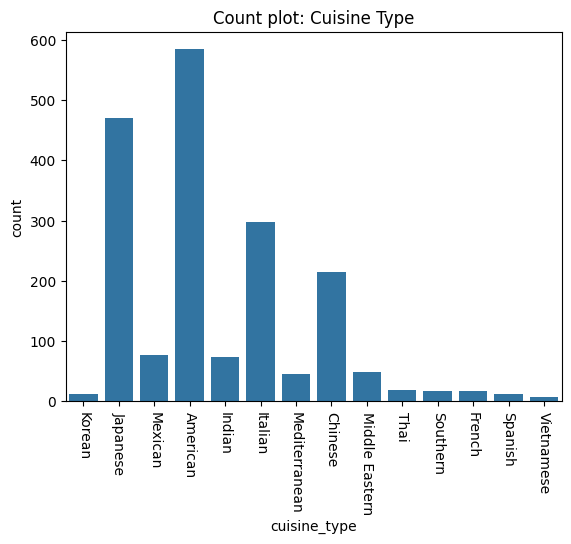

In [174]:
#	cuisine_type count plot
sns.countplot(df,x='cuisine_type')
plt.title('Count plot: Cuisine Type')
plt.xticks(rotation=-90)
plt.show()

Since there are not too many unique values, we can make it as a bar plot. We can see American cuisines are ordered the most by nearly 600, followed by Japanese(~480), Italian(~300), and Chinese(~230). The rest are under 100 orders.

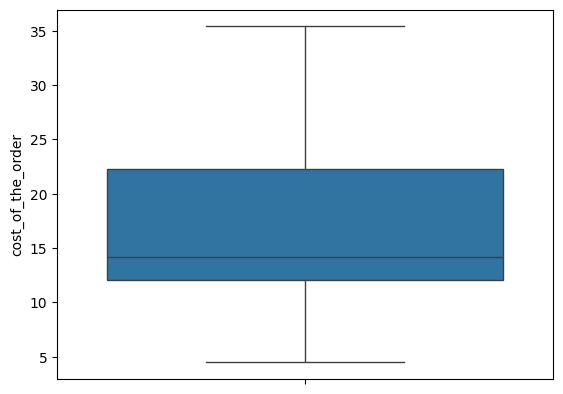

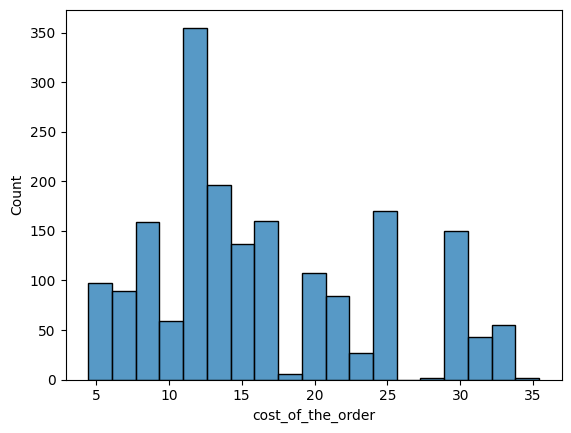

In [175]:
#	cost_of_the_order box plot
sns.boxplot(df,y='cost_of_the_order')
plt.show()
# cost_of_the_order histogram
sns.histplot(df,x='cost_of_the_order')
plt.show()

We can use a box plot and a histogram plot for numerical data. There is no outliers and most of the data are in the range of 12 to 23. The distribution slightly looks like a bimodal shape.

In [176]:
# check unique values of day_of_the_week
df['day_of_the_week'].nunique()

2

<Axes: xlabel='day_of_the_week', ylabel='count'>

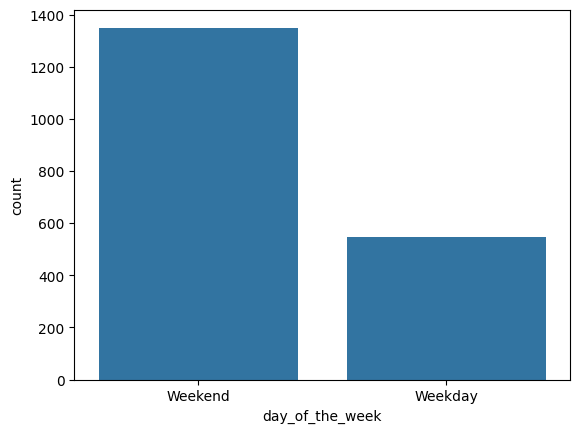

In [177]:
#	day_of_the_week count plot
sns.countplot(df,x='day_of_the_week')

Since there are only 2 unique values, we can make it as a countplot. There are more than twice of weekend orders than weekday orders. We can see that people tend to order food during the weekends mostly.

In [178]:
# check unique values of rating
df['rating'].nunique()

4

<Axes: xlabel='rating', ylabel='count'>

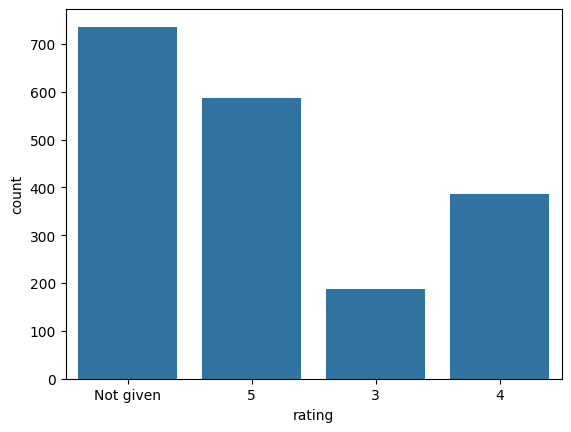

In [179]:
#	rating count plot
sns.countplot(df,x='rating')

Because there are only 4 unique values, we can make this as a bar plot. The most frequent answer was 'Not given.' We can see many people do not give ratings to their orders. The rating is in a range of 3 to 5, with 5 being the most frequent rating, considering it is given. Most of the people were satisfied with their order.

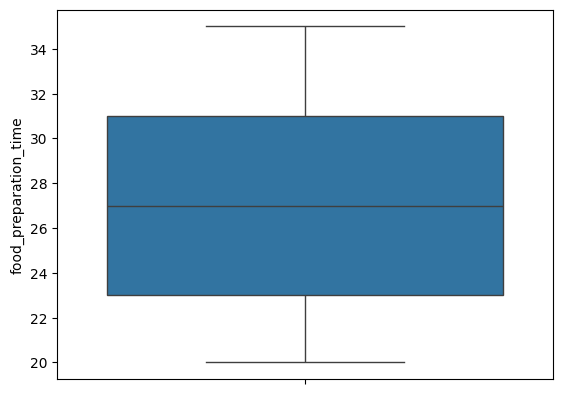

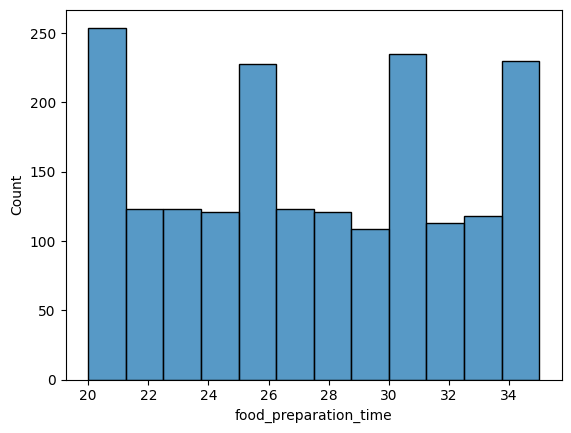

In [180]:
#	food_preparation_time
sns.boxplot(df,y='food_preparation_time')
plt.show()
sns.histplot(df,x='food_preparation_time')
plt.show()

The food preparation is almost evenly distributed except for four spikes in the histogram. In the box plot, we can see that the quartiles have similar sizes. The orders are prepared in a range of 20 minutes to 35 minutes.

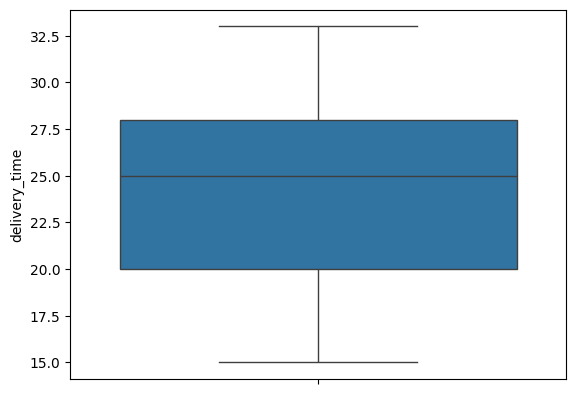

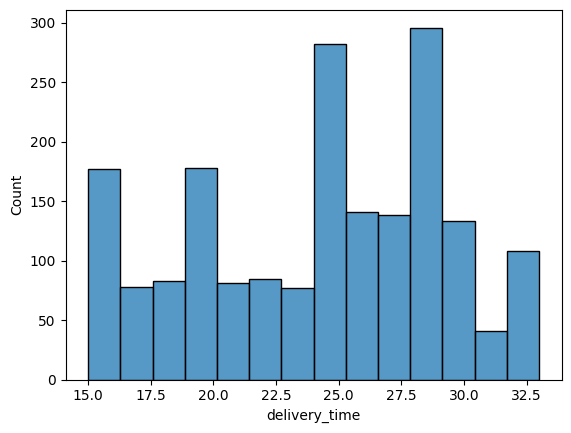

In [181]:
#	delivery_time
sns.boxplot(df,y='delivery_time')
plt.show()
sns.histplot(df,x='delivery_time')
plt.show()

The delivery time is in a range of 15 minutes to 32.5 minutes. While the many of the orders were delivered around 24 minutes to 30 minutes, there are also some orders prepared under 20 minutes.

### Top 5 restaurants by number of orders

In [182]:
# Write the code here
# value_counts(): to calculate the frequency of categorical data (in descending order)
# there are two methods to print out the first 5 rows
# 1. head(): to print out the first 5 rows
df['restaurant_name'].value_counts().head()
# 2. [:5] to print out the first 5 rows
# df['restaurant_name'].value_counts()[:5]

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
The top 5 restaurants in terms of the number of orders received are Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, and Parm, in order. Shake Shack has 219 orders, which is the highest number of orders a restaurant received.


### Most popular cuisine on weekends

In [183]:
# Write the code here
# df[df['day_of_the_week']=='Weekend']: filters the data frame, so it only includes the rows with weekend orders
# df['cuisine_type'].value_counts(): counts the values of the categorical data (cuisine) and order it in a descending order
# [:1] prints out the first row
df[df['day_of_the_week']=='Weekend']['cuisine_type'].value_counts()[:1]

,count
cuisine_type,
American,415


#### Observations:
The most popular cuisine on weekends is American by 415 orders. From question 6, we can also see the most popular cuisine was American, regardless of the day of the week.

### Share of orders costing more than $20

In [184]:
# Write the code here
# df[df['cost_of_the_order']>20]: filters the dataframe, so it only has the rows that the cost_of_the_order is greater than 20
# shape attributes give the dimensions of the dataframe (rows, columns)
# shape[0]: outputs the first element of the shape attribute (rows)
# multiply it with 100, so it comes out in a percentage form
# round it so the output does not look too messy
round(df[df['cost_of_the_order']>20].shape[0]/df.shape[0] * 100,2)

29.24

#### Observations:
The percentage of the orders that cost more than 20 dollars is 29.24%. This means the majority(~70%) of the orders were 20 dollars or under.

### Mean order delivery time

In [185]:
# Write the code here
# find the mean of the order delivery time, by making it into a series (df['delivery_time']) and using the mean function
# round it to the second digit to prevent a messy output
round(df['delivery_time'].mean(),2)

24.16

#### Observations:
The mean order delivery time is 24.16 minutes.

### Top 3 most frequent customers

The company plans to give 20% discount vouchers to its three most frequent customers, so we identify those customer IDs and the number of orders they placed.

In [186]:
# Write the code here
# find the most frequent customer_id by using value_counts (output in descending order)
# use [:3] or head(3) to print out the top 3 most frequent customers
df['customer_id'].value_counts()[:3]

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:
The top 3 most frequent customer IDs are 52832, 47440, 83287. They orders 13, 10, and 9 times, respectively. These 3 customers will be receiving the 20% discount vouchers from the company.

### Multivariate Analysis

### Exploring relationships between variables

In [187]:
# Write the code here
# call the dataframe again to see what to compare
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


We will not be using order_id, customer_id, and restaurant_name because they have too many unique values, and the first two are not continuous, too.

####For categorical vs. categorical:
cuisine type vs. day of the week, cuisine type vs. rating

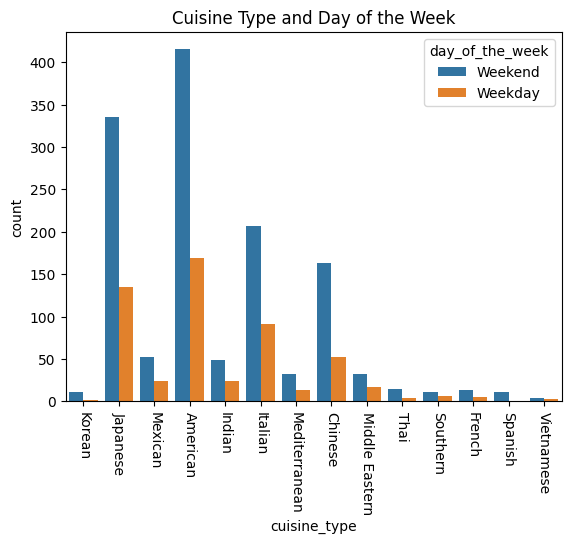

In [188]:
# cuisine type vs. day of the week
sns.countplot(df, x='cuisine_type', hue='day_of_the_week');
plt.xticks(rotation=-90)
plt.title('Cuisine Type and Day of the Week')
plt.show()

Considering there are more orders during the weekends, we can see that the cuisine distribution is similar from the weekdays to the weekends.

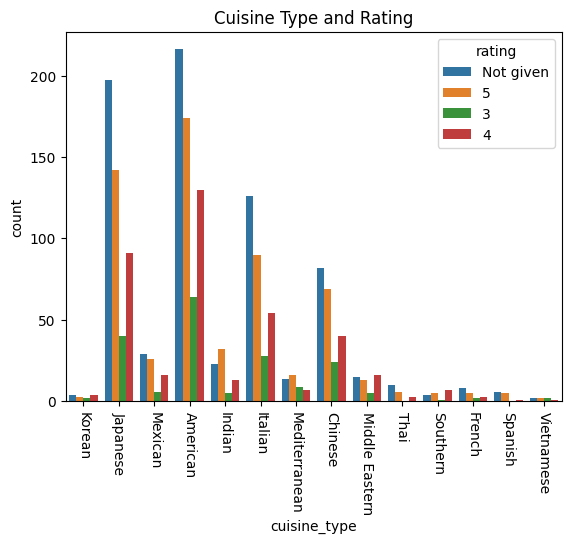

In [189]:
# cuisine type vs. rating
sns.countplot(df, x='cuisine_type', hue='rating');
plt.xticks(rotation=-90)
plt.title('Cuisine Type and Rating')
plt.show()

We can see the ratings have similar distributions among the cuisines.

####For categorical vs. numerical:
cuisine type vs. cost of the order, cuisine type vs. food preparation time, day of the week vs. delivery time, rating vs. cost of the order, rating vs. food preparation time, rating vs. delivery time

#####cuisine type vs. cost of the order



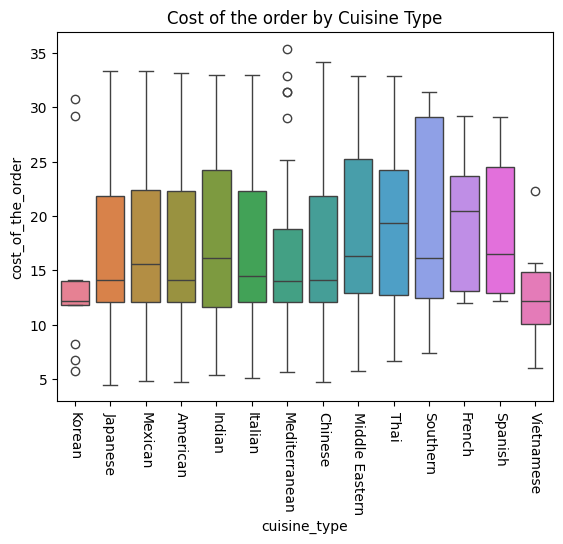

In [190]:
# cuisine type vs. cost of the order
sns.boxplot(df, x = 'cuisine_type', y = 'cost_of_the_order', hue='cuisine_type')
plt.xticks(rotation = -90)
plt.title('Cost of the order by Cuisine Type')
plt.show()

The cost of the order of Korean cuisines are mostly similar, around 13 dollars. However, there are few outliers. The cost of the order of the Mediterranean cuisines are relatively low; however, has few expensive outliers. The cost of the order of Vietnamese cuisines is similar to the Mediterranean cuisines. The cost of the order of other cuisines mostly have a large range of the cost, mostly ranging from 5 to 35.

#####cuisine type vs. food preparation time

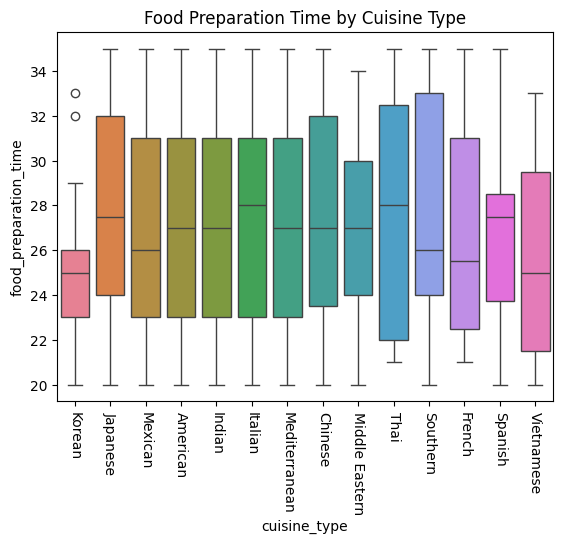

In [191]:
# cuisine type vs. food preparation time
sns.boxplot(df, x = 'cuisine_type', y = 'food_preparation_time', hue='cuisine_type')
plt.xticks(rotation = -90)
plt.title('Food Preparation Time by Cuisine Type')
plt.show()

The food preparation time of the Korean cuisines ranges relatively shorter than that of other cuisines. However, Korean cuisines have some outliers. Other cuisines tend to vary from 20 minutes to 35 minutes. Out of them, the Middle Eastern cuisine and Vietnamese cuisine have a shorter maximum food preparation time.

#####day of the week vs. delivery time

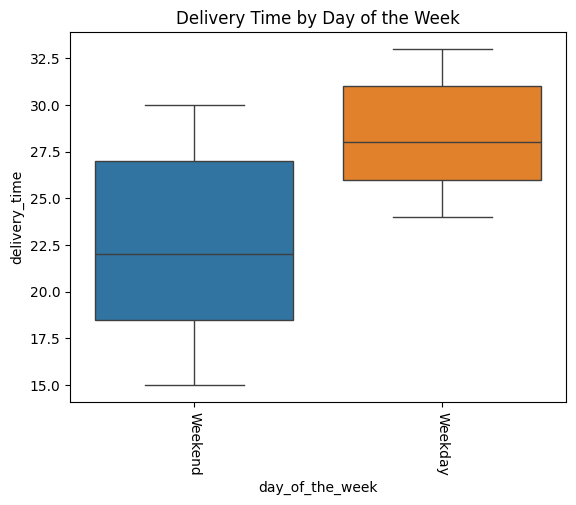

In [192]:
# day of the week vs. delivery time
sns.boxplot(df, x = 'day_of_the_week', y = 'delivery_time', hue='day_of_the_week')
plt.xticks(rotation = -90)
plt.title('Delivery Time by Day of the Week')
plt.show()

The delivery time of the weekends is distinctively shorter than the that of the weekdays. We can assume it is because weekdays have less traffic problems since people do not drive to go to work or school. During the weekends, the delivery time varies from 15 minutes to 30 minutes, while during the weekdays, the time varis from 24 minutes to 33 minutes.

#####rating vs. cost of the order

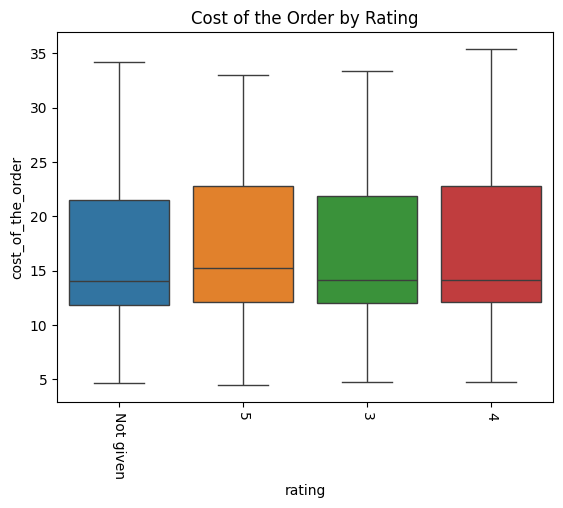

In [193]:
# rating vs. cost of the order
sns.boxplot(df, x = 'rating', y = 'cost_of_the_order', hue='rating')
plt.xticks(rotation = -90)
plt.title('Cost of the Order by Rating')
plt.show()

The cost of order distribution is very similar among all types of ratings. We can assume that ratings are not affected by the cost of the order.


#####rating vs. food preparation time

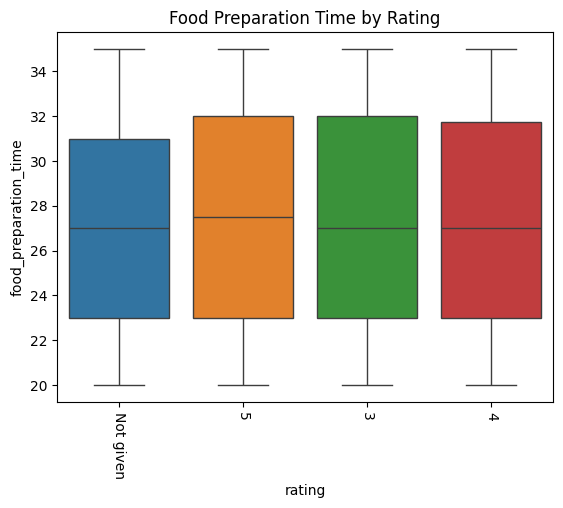

In [194]:
# rating vs. food preparation time
sns.boxplot(df, x = 'rating', y = 'food_preparation_time', hue='rating')
plt.xticks(rotation = -90)
plt.title('Food Preparation Time by Rating')
plt.show()

The food preparation time distribution ranges similarly among all types of ratings. We can think that ratings are not affected by the food preparation time.

#####rating vs. delivery time

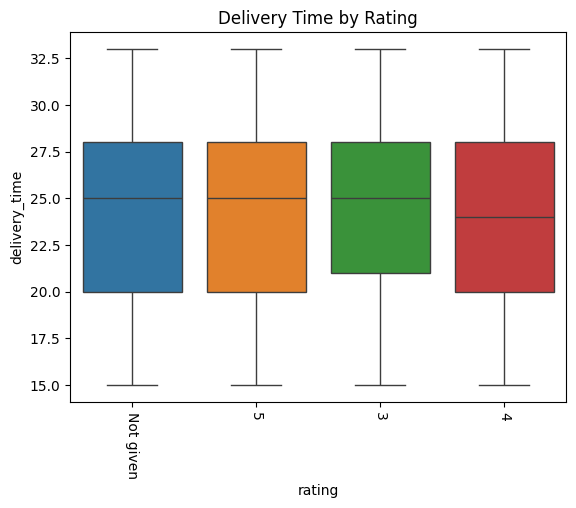

In [195]:
# rating vs. delivery time
sns.boxplot(df, x = 'rating', y = 'delivery_time', hue='rating')
plt.xticks(rotation = -90)
plt.title('Delivery Time by Rating')
plt.show()

The cost of order varies similarly among all types of ratings. We can say that ratings are not affected by the cost of the order.

####For numerical vs. numerical:
correlation between cost of the order, food preparation time, delivery time

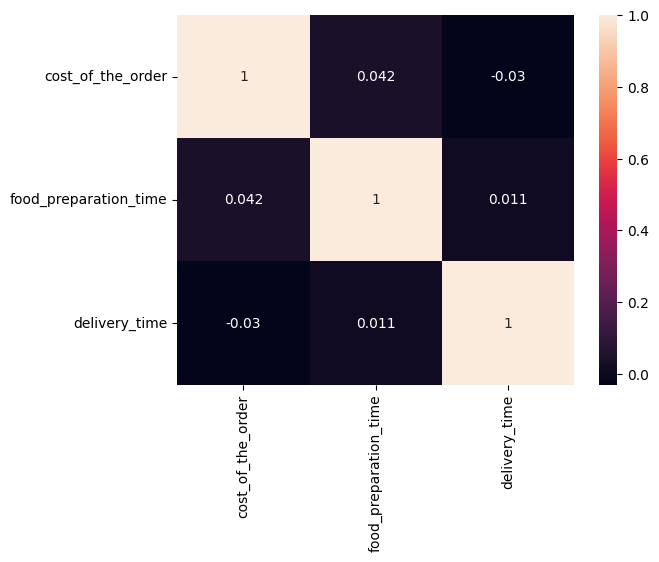

In [196]:
# compare all the numerical variables by using heatmap
sns.heatmap(df[['cost_of_the_order','food_preparation_time','delivery_time']].corr(),annot=True)
plt.show()

For the three variables, none of them have a strong correlation with each other. cost_of_the_order and food_preparation_time have the strongest correlation, but it is only 0.04, which is not considered significant enough.

### Restaurants eligible for a promotional offer

To qualify for a promotional advertisement, a restaurant must have more than 50 ratings and an average rating above 4. We find the restaurants meeting both criteria.

In [197]:
# Write the code here
# make a dataframe without 'Not given' ratings by copying it so the original dataframe is not modified
df_int_rating =  df[df['rating']!='Not given'].copy()
# check the dataframe
df_int_rating.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24
5,1477224,147468,Tamarind TriBeCa,Indian,25.22,Weekday,3,20,24
7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3,33,30


In [198]:
# change the ratings into integer type
df_int_rating['rating'] = df_int_rating['rating'].astype(int)
# check the dataframe (whether rating changed into int)
df_int_rating.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1162 entries, 2 to 1896
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1162 non-null   int64  
 1   customer_id            1162 non-null   int64  
 2   restaurant_name        1162 non-null   object 
 3   cuisine_type           1162 non-null   object 
 4   cost_of_the_order      1162 non-null   float64
 5   day_of_the_week        1162 non-null   object 
 6   rating                 1162 non-null   int64  
 7   food_preparation_time  1162 non-null   int64  
 8   delivery_time          1162 non-null   int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 90.8+ KB


In [199]:
# show the restaurants that have more than 50 ratings
rest_moreThan50 = df_int_rating['restaurant_name'].value_counts()[df_int_rating['restaurant_name'].value_counts()>50].reset_index()['restaurant_name']
# check the series
rest_moreThan50

,restaurant_name
0,Shake Shack
1,The Meatball Shop
2,Blue Ribbon Sushi
3,Blue Ribbon Fried Chicken


In [200]:
# filter the dataframe so it only includes restaurants that has more than 50 ratings
# use copy to not modify the original data
df_moreThan50_rating = df_int_rating[df_int_rating['restaurant_name'].isin(rest_moreThan50)].copy()
# check the dataframe
df_moreThan50_rating.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.2,Weekend,3,25,15
12,1476966,129969,Blue Ribbon Fried Chicken,American,24.3,Weekend,5,23,17
15,1477414,66222,Shake Shack,American,16.2,Weekend,5,33,25
19,1477354,67487,Blue Ribbon Sushi,Japanese,16.2,Weekend,4,35,26
22,1478287,150599,Shake Shack,American,29.1,Weekday,5,21,30


In [201]:
# check the average rating of the restuarants that has more than 50 ratings
df_moreThan50_rating.groupby(['restaurant_name'])['rating'].mean()

,rating
restaurant_name,
Blue Ribbon Fried Chicken,4.328125
Blue Ribbon Sushi,4.219178
Shake Shack,4.278195
The Meatball Shop,4.511905


#### Observations:
Since all of the outputs are more than 4, it means all four restaurants have an average rating higher than 4. They also qualify for having more than 50 ratings. The company can provide promotional offer in the advertisement of the restaurants to Shake Shack, The Meatball Shop, Blue Ribbon Sushi, and Blue Ribbon Fried Chicken.

### Net revenue generated across all orders

The company charges restaurants 25% on orders costing more than $20 and 15% on orders costing more than $5. We use this to estimate the net revenue generated across all orders.

In [202]:
# Write the code here
# Method 1
# calculate the revenue by adding all the orders greater than $20 and multiply .25
# and adding all the orders between 5 and 20 and multiply .15
df[df['cost_of_the_order']>20]['cost_of_the_order'].sum()*.25 + df[(df['cost_of_the_order']<=20)&(df['cost_of_the_order']>5)]['cost_of_the_order'].sum()*.15

6166.303

In [203]:
# Method 2
# make a function that would give the revenue based on the cost_of_the_order
def revenue(cost):
  if cost > 20: return cost*.25
  elif cost > 5: return cost*.15
  else: return 0

In [204]:
# apply the function to all rows (using cost_of_the_order as the input) and input it in a new column called 'revenue'
df['revenue'] = df['cost_of_the_order'].apply(revenue)

In [205]:
# check if the function works
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,revenue
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20,7.6875
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23,1.8120
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,1.8345
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,7.3000
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,1.7385


In [206]:
# caculate the sum of the revenue
df['revenue'].sum()

6166.303

#### Observations:
The net revenue generated by the company across all orders is 6166.30 dollars.

### Orders taking more than 60 minutes to deliver

We look at the total time from order placement to delivery (preparation plus delivery) and find the share of orders exceeding 60 minutes.

In [207]:
# Write the code here
# make a new column called 'total_time' that adds the 'food_preparation_time' and the 'delivery_time'
df['total_time'] = df['food_preparation_time'] + df['delivery_time']
# divide the number of rows that the 'total_time' is greater than 60 by the total number of rows in the dataframe
# and multiply it with 100 so it will show up as a percentage form
# round it to the second digit to prevent a messy outcome
round(df[df['total_time'] > 60].shape[0]/df.shape[0] * 100,2)

10.54

#### Observations:
The precentage of orders that take more than 60 minutes to get delivered from the tiem the order is placed is 10.54%. This means that most of the orders (~90%) are delivered in 60 minutes, which explains the good quality service of the food company.

### Delivery time on weekdays vs weekends

In [208]:
# Write the code here
# mean delivery time on weekdays
mean_delivery_time_weekday = df[df['day_of_the_week']=='Weekday']['delivery_time'].mean()
# print result, with rounding the output to the first two digits
print('mean delivery time on weekdays:',round(mean_delivery_time_weekday,2))
# mean delivery time on weekends
mean_delivery_time_weekend = df[df['day_of_the_week']=='Weekend']['delivery_time'].mean()
# print result, with rounding the output to the first two digits
print('mean delivery time on weekends:',round(mean_delivery_time_weekend,2))

mean delivery time on weekdays: 28.34
mean delivery time on weekends: 22.47


#### Observations:
The mean delivery time of the orders on the weekdays and weekends are 28.34 minutes and 22.47 minutes, respectively. The mean delivery time on the weekdays take longer than the weekends. It is possible that the traffic during the peak hours can be bad, during the weekdays. Because people go and come back to work, there can be more cars, making the delivery hours longer than the weekends.


### Conclusion and Recommendations

The findings and business recommendations from the analysis are summarized below.

### Conclusions:
We analyzed the data from the FoodHub, a food ordering smartphone application company. The data included the order ID, customer ID, restaurant name, cuisine type, cost of the order, day of the week, rating given, food preparation time, and delivery time. We further calculated the revenue this company will be taking. We explored through the variables and the relationships between the variables. We also found the restaurants with the most orders and ratings, what cuisine is the most popular, and which customer ID ordered the most.

*   While a lot of ratings were not given, still most of the ratings were around 4 and 5, with few 3s. Many customers were satisfied with the restaurant and the service of the company.
*   American cuisines were the most ordered cuisines. Shake Shack was the most ordered restaurant.
*   Customers tend to order more during the weekends, and it is also delivered faster during the weekends.
*   Most orders lied under 20 dollars, which is relatively cheap, considering the New York market prices for dining.
*   Ratings are not affected by the cost of the order, food preparation time, and the delivery time.
*   Korean cuisines are prepared faster than other cuisines and the cost of the order was also distinctively cheaper.
*   Most of the orders (~90%) were delivered under 60 minutes starting from the order being placed.







### Recommendations:

*  To make more people fill out the rating, we should make sure the ratings can be done quickly. We should also give small benefits for the customers who finished the ratings, so more people can participate.
*  We should make sure to include other cuisine restaurants to increase the revenue from them, too.
*  Because customers order more in the weekends usually, we should think of making special events during the weekdays to encourage orders during the weekdays, too.
*  Since majority of the orders are cheap, we can advertise our company as providing cheap food options.
*  We should collect more data to find what affects ratings, other than the taste itself.
*  Because we have short delivery time, we should advertise our company for having fast delivery from the order placed.
*  We should seek a method to gain more revenues out of this business.

---